# Feature Extraction: Spectral Features

After you save your impulse, open **Spectral features** in the left sidebar. This page decides **how each window of your data gets turned into a handful of numbers (features)** that the neural network learns from.

You can find more details [here](https://docs.edgeimpulse.com/studio/projects/processing-blocks/blocks/spectral-analysis).

You'll see two sections of settings: **Filter** (cleans the signal first) and **Analysis** (extracts the features). There is also a **Normalize features** option on the next tab.

## How to Learn: Experiment!

Use this document as your manual to understand each setting. There is no single "right" setting. The best choice depends on your data, so **try things and see what happens**.

1. Change **one** setting.
2. Click **Save parameters**.
3. Go to **Generate features** and look at the **Feature Explorer** (do the classes separate?).
4. Train the model and check the accuracy, loss and confusion matrix.
5. Write down what you changed and what happened.

If you change two things at once, you won't know which one made the difference. Keep a simple notes table like this if you want:

| What I changed | Feature Explorer | Accuracy | Loss | Notes |
|---|---|---|---|---|
| | | | | |
| | | | | |

## The Autotune Button

**Autotune parameters** looks at your whole dataset and suggests a set of parameters. It's a useful starting point, but it is a search, not a guarantee. Try its suggestion, then experiment around it.

# Filter Settings

The filter cleans the signal **before** features are calculated.

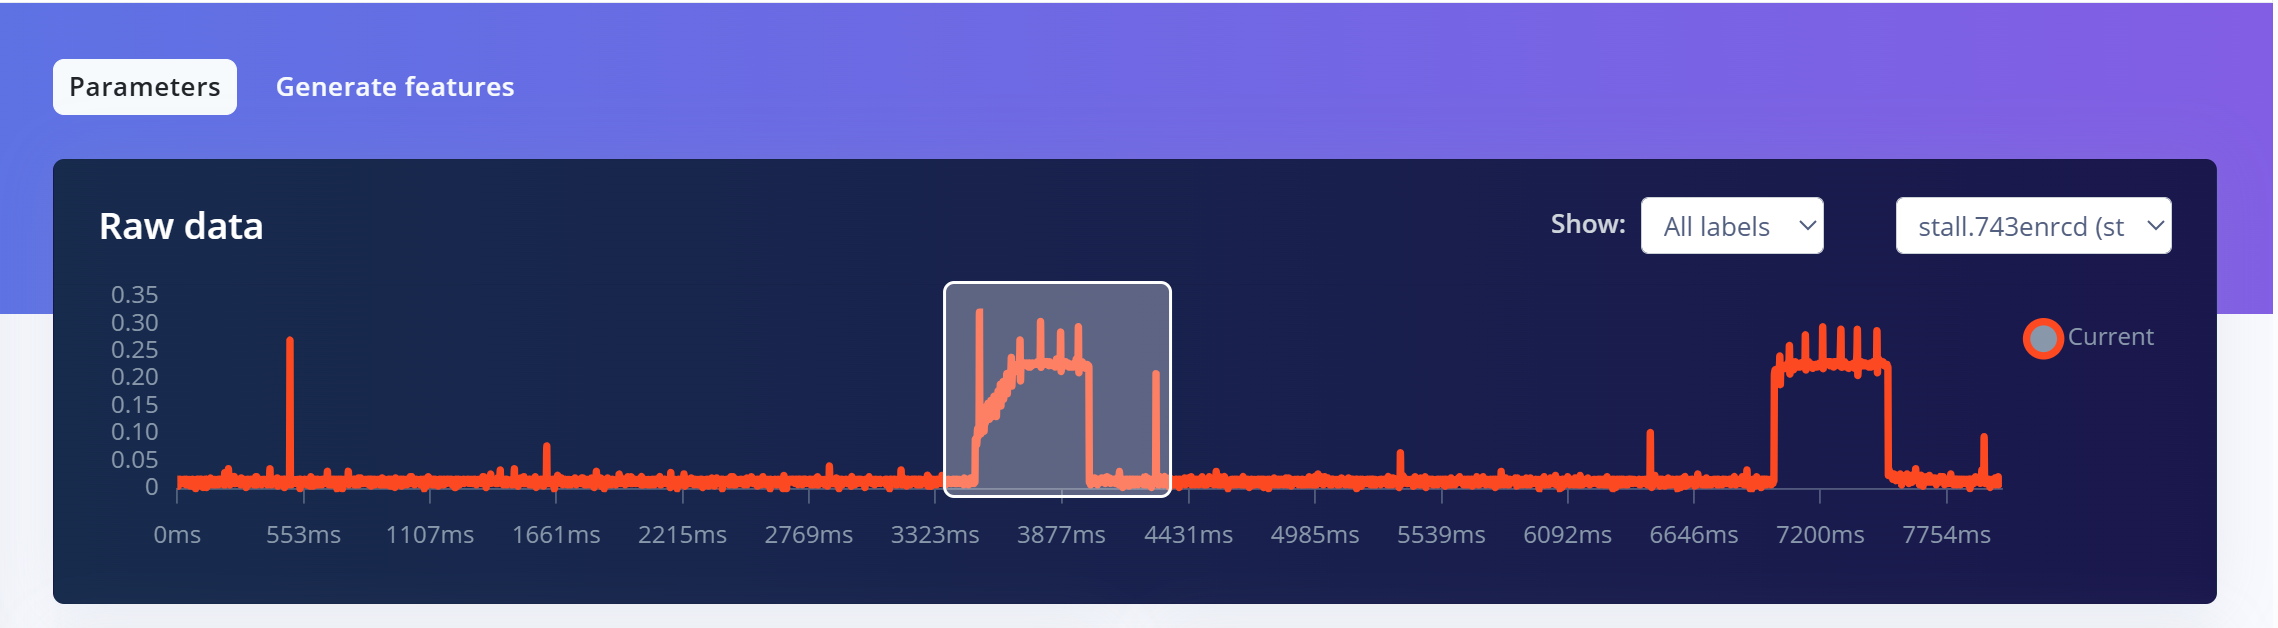

The time-series data inside the window of your sample can be filtered, which often helps to smooth out the signal or drop unwanted artifacts. In the image above, a “window” is shown inside the white box; only the readings inside that box will be used for filtering and calculating

### Scale Axes

Multiplies every raw value by this number. **Leave this at 1**

- **Increase:** all values get bigger.
- **Decrease:** all values get smaller.
- The *shape* of your signal stays the same; only the numbers change. 
- It's useful for converting raw sensor readings into real units (for example, raw readings into amps). We don't change this value because the Arduino code converts Raw ADC values back to real physical values.

### Input Decimation Ratio

Downsamples the signal by keeping only some of the readings. A ratio of 1 keeps everything, 2 keeps every 2nd reading, 4 keeps every 4th, and so on.

- **Increase:** fewer samples, so fewer features and less computing. Fast details disappear, because the highest frequency you can see is half the new sampling rate. Each frequency bin also gets narrower, which gives finer detail in the low frequencies.
- **Decrease (back to 1):** keeps all the detail, but needs more computing.

### Type (Filter)

Choose which kind of frequencies to remove.

- **Low-pass:** keeps slow changes and removes fast ones. This smooths out noise.
- **High-pass:** keeps fast changes and removes slow ones.
- **None:** no filtering.

### Cut-off Frequency 

_(appears for low-pass and high-pass only)_

The frequency where the filter starts cutting, in hertz.

- **Increase (low-pass):** more fast changes get through.
- **Decrease (low-pass):** only slower changes get through, so the signal gets smoother.
- High-pass works in the opposite direction.
- Frequency bins beyond the cut-off are also removed from the features, which makes the model smaller.

### Order

_(appears for low-pass and high-pass only)_

How sharp the cut-off is. It must be an even number.

- **Increase:** a sharper cut-off, but more delay (latency).
- **Decrease:** a gentler cut-off, with less delay.
- **0:** the signal is not filtered, but unwanted frequency bins are still removed.

# Analysis Settings

### Analysis Type

Choose how to turn each window into features.

- **FFT:** tells you *which frequencies are present* in the window. It works well for repeating patterns like vibrations.
- **Wavelet:** also looks at frequency, but keeps some information about *when* things happen. It works well for sudden changes or irregular signals.

Switching the type changes which settings appear below. Try both and compare the results!

## $\rightarrow$ If you chose FFT

An FFT breaks a signal into the different frequencies that make it up. Think of the bouncing bars on a music player's equalizer.

### FFT Length

How many readings go into each FFT. It controls how many frequency bins you get.

- **Increase:** frequencies get separated into more bins (finer detail), but you get more features and a bigger model.
- **Decrease:** several frequencies get averaged together into the same bin, so you get fewer features and a smaller model.
- If your window has more readings than the FFT length, the window is split into smaller frames and an FFT is done on each. For each bin, the largest value across the frames is kept.
- Compare the FFT length with the number of readings in your window (sampling rate × window size).

### Take log of spectrum?

Applies a log scale to each frequency bin.

- **Checked:** small signals are easier to see, but big signals are squeezed together.
- **Unchecked:** big signals dominate, and small ones may be hard to see.

### Overlap FFT frames?

Whether neighbouring frames share half their readings.

- **Checked:** helps catch short events that would fall on the edge between two frames.
- **Unchecked:** frames don't overlap, which is a bit faster (lower latency). It doesn't change model size or RAM.
- It only matters when your window is long enough to contain more than one frame.

### Improve low frequency resolution?

It decimates the signal to improve low frequency resolution, which is the same idea as the **input decimation ratio** above, done automatically.

- **Checked:** the signal is downsampled, so slow changes can be seen in more detail, but fast details are lost.
- **Unchecked:** the signal is left as it is.
- The documentation doesn't say exactly how much it downsamples. Toggle it and compare the **Spectral power** graph to see what changes.

## $\rightarrow$ If you chose Wavelet

A wavelet slides a small "pattern shape" across your signal and measures how well it matches at different scales. It splits the signal into several levels of detail.

### Wavelet Decomposition Level

How many times the signal is split into finer and coarser parts.

- **Increase:** more detail about the signal, but more features and more computing. Very high levels can also introduce noise.
- **Decrease:** fewer features and faster, but less detail.
- Each level adds about 14 features (for example, the documentation's 4-level example gives 70 features). They include things like mean, median, percentiles, RMS, skewness, kurtosis and entropy.

### Wavelet

The shape of the pattern that gets slid across the signal (also called the kernel). There are many to choose from.

- The documentation says the best choice is often the wavelet that looks like the pattern you're looking for in your signal.
- Try a few, and compare the Feature Explorer and the results.

# The Graphs

<img src = "imgs/wavelet_graphs.png" width = "45%"> <img src = "imgs/fft_graphs.png" width = "45%">

These are on the right side of the page, and they show what your settings are doing to the selected sample.

- **Filter response:** how much each frequency is reduced by the filter (only if a filter is on).
- **After filter:** the signal after filtering.
- **Spectral power:** power at each frequency (FFT only).
- **Wavelet function:** the shape of the wavelet you chose (wavelet only).
- **Wavelet approximation:** a simplified version of your signal (wavelet only).

Change a setting, save, and watch which graphs change. It's a quick way to see what each setting does.

# Data Normalization

On the **Generate features** tab there is a **Normalize features** option.

This will learn the mean and standard deviation of each output column during the feature generation step, and apply a normalization step during training and inference. Recommended when raw numeric ranges differ by more than ~10×

<img src = "imgs/normalize.png" width = "50%">

_In some cases, you may want to normalize your data before training a model. This is especially useful when your data has different scales or units, as it can help improve the performance of your model._

- **Selected:** Edge Impulse learns the average and spread of each feature, and rescales them so they're on a similar scale. This is recommended when feature values differ a lot in size.
- **Not Selected:** features are used as they are.

[Why Normalize?](https://docs.edgeimpulse.com/studio/projects/processing-blocks#why-normalize) for more details.

# Generate features and check the Feature Explorer

<img src = "Assets/feature_explorer" width = "50%">

After saving your parameters:

1. Open the **Generate features** tab and click **Generate features**.
2. Look at the **Feature Explorer**. Each dot is one window.
3. If dots of different classes form separate groups, that's a good sign. If they overlap, that's a reason to investigate, not a reason to give up. The explorer only shows 2 or 3 features at a time, while the model sees all of them.
4. Train your model, and compare accuracy, loss and the confusion matrix with your earlier tries.

# Behind The Scenes 

_(good to know)_

For each window, Edge Impulse does this in order:

1. Applies the **filter** (if you chose one).
2. **Subtracts the average (mean)** of the window from the signal.
3. Calculates the features using the **analysis type** you picked (FFT or wavelet).

_What this means_: For FFT, step 2 means that a flat stall at 0.23 A and a flat idle level at 0.05 A look much alike, because the height is removed and only the wiggles remain. FFT can only tell the two states apart if they **wiggle differently** (for example, more noise or ripple in one of them). If both states are smooth and flat, FFT has little to work with, and the model may confuse a stall with idle. In that case, the Feature Explorer will show the two classes overlapping.

_Think about it_: if the difference between your classes is *how high* the signal sits, which analysis type or setting might keep that information? Experiment and compare.